In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os, glob
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density, MC_stack_plot_weight

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

Welcome to JupyROOT 6.26/04


In [2]:
plot_directory = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg"
# plot_directory = os.path.dirname(file_path)
if not os.path.exists(plot_directory):
    os.makedirs(plot_directory)

In [3]:
tree = 'etapip_gg'
base_cut = 'Dp_M>0'
# output_dir = os.path.join("MC15rd", f"histograms_{tree}")
# os.makedirs(output_dir, exist_ok=True)

In [4]:
base_path="/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"
dir_list = [
    f"{base_path}/15rd_eta_e7_18_4S_v3/{tree}/min_unc_search/0.83/weighted",
    f"{base_path}/15rd_eta_e20_b26_v1/{tree}/min_unc_search/0.83/weighted",
    f"{base_path}/15rd_eta_e20_e26_4S_v2/{tree}/min_unc_search/0.83/weighted",
    f"{base_path}/15rd_eta_e21_5S_scan_v1/{tree}/min_unc_search/0.83/weighted",
    f"{base_path}/15rd_eta_mori_off_v1/{tree}/min_unc_search/0.83/weighted",
]

In [5]:
# Sample tags
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']

# Aggregate all ROOT files by tag
file_map = {tag: [] for tag in tags}
for tag in tags:
    for d in dir_list:
        path = os.path.join(d, f"weighted_{tag}.BCS.root")
        if os.path.exists(path):
            file_map[tag].append(path)

In [6]:
file_map['ccbar']

['/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p/15rd_eta_e7_18_4S_v3/etapip_gg/min_unc_search/0.83/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p/15rd_eta_e20_b26_v1/etapip_gg/min_unc_search/0.83/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p/15rd_eta_e20_e26_4S_v2/etapip_gg/min_unc_search/0.83/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p/15rd_eta_e21_5S_scan_v1/etapip_gg/min_unc_search/0.83/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7

In [7]:
num_files = 0
for tag in tags:
    num_files += len(file_map[tag]) 
print(num_files)

33


In [8]:
# Load one file to get variable list
chain = ROOT.TChain(tree)
for path in file_map['ccbar']:
    chain.Add(path)
variables = [b.GetName() for b in chain.GetListOfBranches()]
variables = ['Dp_M','ds_weight']

Error in <TList::Clear>: A list is accessing an object (0x55f254ca4b20) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x55f25714b9d0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x55f25714c650) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x55f25714c970) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x55f25714cde0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x55f25714d280) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x55f25714d650) already deleted (list name = TList)


In [9]:
dataframes = {}
for tag in tags:
    dfs = [get_pd(file=fp, tree=tree, base_filter=base_cut, variables=variables) for fp in file_map[tag]]
    dataframes[tag] = pd.concat(dfs, ignore_index=True)

In [10]:
for tag in tag_order:
    dataframes[tag]["ds_weight"] = dataframes[tag]["ds_weight"]*(1/4)

In [11]:
cut1 = "Dp_M>0"

In [12]:
for tag in tags:
    dataframes[tag] =dataframes[tag].query(cut1)

In [13]:
scale = 1
# luminosity=r"$1000\; \mathrm{fb}^{-1}$"
luminosity=""

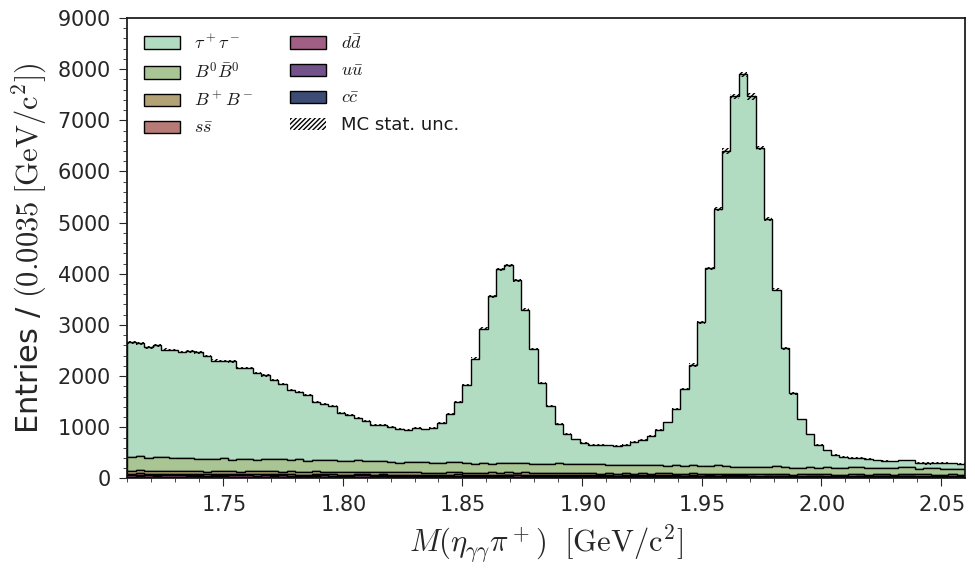

In [14]:
data_list = [dataframes[tag]["Dp_M"] for tag in tag_order]
scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]

# data_list = [df["Dp_M"] for df in dataframes.values()]
# scale_list = [df["ds_weight"] for df in dataframes.values()]

MC_stack_plot_weight(
    data=data_list,
    var="Dp_M",
    scale=scale_list,
    xrange=(1.71,2.06),
    nbins=100,
    xlabel=r"$M(\eta_{\gamma\gamma}\pi^+)$",
    labels=[labels[tags.index(tag)] for tag in tag_order],
    # title="MC15rd: $D^+ \\to \\eta \\pi^+$",
    unit="[GeV/c^2]",
    force_range=(1.71,2.06),
    ncol=2,
    legend_loc="upper left"
)
plt.tight_layout()
img_path = plot_directory + "/MC15rd_etapip_gg_after_BDT_Dp_M_weighted.png"
plt.savefig(img_path)

In [15]:
tag_order

['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']

In [21]:
# plot_labels

In [85]:
# from plothist import add_luminosity


/tmp/ipykernel_42321/2428691210.py:1: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  from plothist import add_luminosity


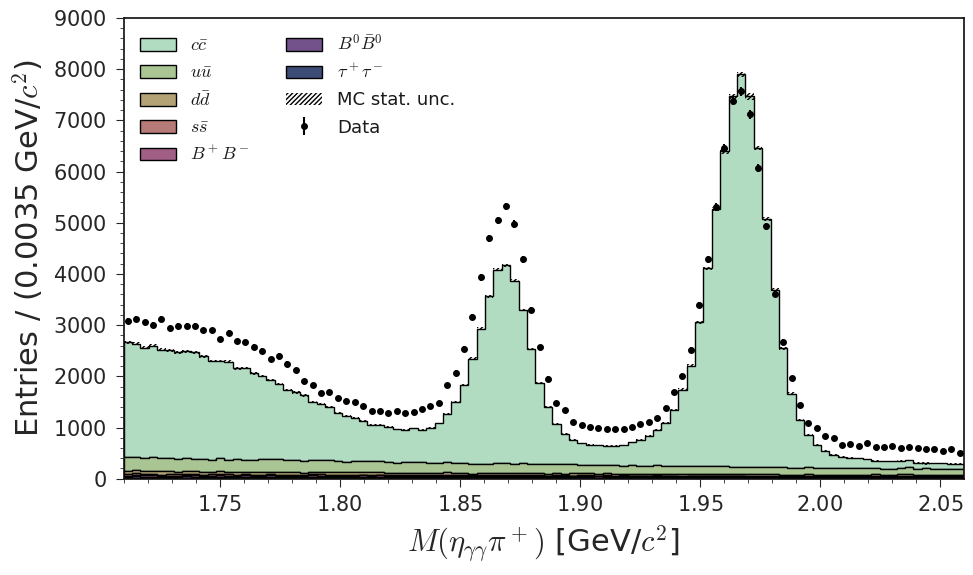

In [17]:
base_path="/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"

data_dir_list = [
    f"{base_path}/etahp_13_4S_off_v1/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_13_4S_v2/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_23_4S_off_v1/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_23_4S_v1/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_23_5Sscan_10657_v1/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_23_5Sscan_10706_v1/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_23_5Sscan_10751_v1/{tree}/min_unc_search/0.83",
    f"{base_path}/etahp_23_5Sscan_10810_v1/{tree}/min_unc_search/0.83"
]

In [18]:
data_dfs = []
for d in data_dir_list:
    for file in glob.glob(os.path.join(d, "*.BCS.root")):
        try:
            df = get_pd(file=file, tree=tree, base_filter=base_cut, variables=["Dp_M"])
            data_dfs.append(df)
        except Exception as e:
            print(f"[Warn] Cannot load {file}:", e)

# data_df = pd.concat(data_dfs, ignore_index=True)
# data_hist, _ = np.histogram(data_df["Dp_M"], bins=xbins)
# data_errors = np.sqrt(data_hist)

# === 데이터 포인트와 에러바 그리기 ===
# ax.errorbar(bin_centers, data_hist, yerr=data_errors,
#             fmt='ko', markersize=4, label="Data")

# # === 축, 제목, 범례 ===
# ax.set_xlim(*xrange_)
# ax.set_xlabel(r"$M(\eta_{\gamma\gamma}\pi^+)$ [GeV/$c^2$]")
# ax.set_ylabel(f"Entries / ({bin_width:.3f} GeV/$c^2$)")
# ax.legend(loc="upper left", prop={'size':13}, ncol=2)
# ax.set_title(r"MC Stack + Data: $D^+ \to \eta' \pi^+$")

# plt.tight_layout()
# plt.savefig("mc_stack_plus_data.pdf")
# plt.show()

NameError: name 'xbins' is not defined

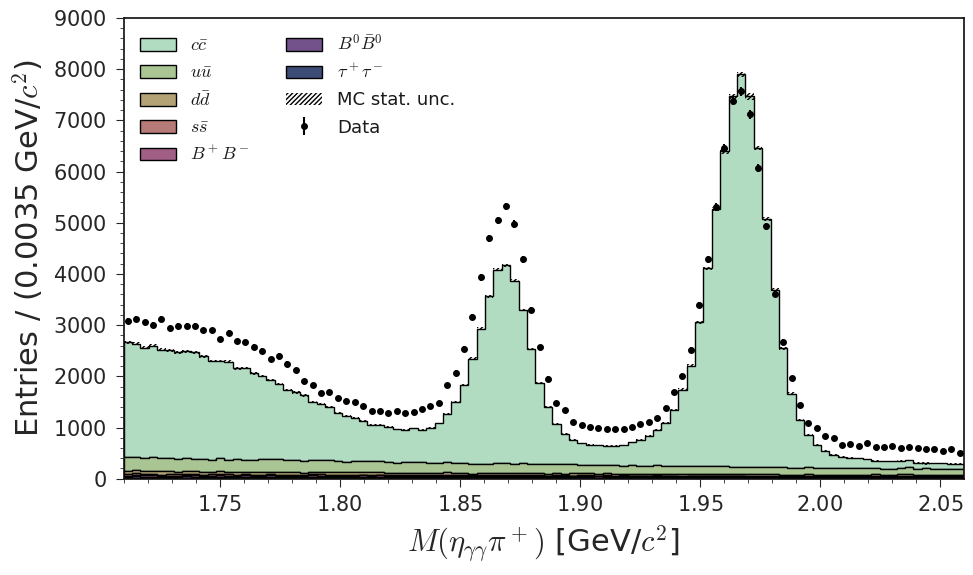

In [22]:
# # === 스택용 리스트 ===
data_list = [dataframes[tag]["Dp_M"] for tag in tag_order]
scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
plot_labels = [labels[tags.index(tag)] for tag in tag_order]
plot_labels = plot_labels[::-1]
# === bin 설정 ===
xrange_ = (1.71, 2.06)
nbins = 100
xbins = np.linspace(*xrange_, nbins + 1)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]

# === 스택 히스토그램 그리기 ===
fig, ax = plt.subplots(figsize=(10, 6))

colors = b2helix(len(data_list))

# 평탄화하여 통계 오차 계산
flat_data = np.concatenate([np.asarray(d) for d in data_list])
flat_weights = np.concatenate([np.asarray(w) for w in scale_list])

sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]

# 스택 히스토그램
ax.hist(data_list, bins=xbins, weights=scale_list,
        histtype='stepfilled', stacked=True, label=plot_labels,
        color=colors, edgecolor='black')

# MC 통계 오차 막대
ax.bar(bin_centers, 2 * np.sqrt(sum_w2), width=bin_width,
       bottom=sum_w - np.sqrt(sum_w2), color='black',
       hatch='///////', fill=False, lw=0, label="MC stat. unc.")

data_df = pd.concat(data_dfs, ignore_index=True)
data_hist, _ = np.histogram(data_df["Dp_M"], bins=xbins)
data_errors = np.sqrt(data_hist)

# === 데이터 포인트와 에러바 그리기 ===
ax.errorbar(bin_centers, data_hist, yerr=data_errors,
            fmt='ko', markersize=4, label="Data")

# === 축, 제목, 범례 ===
ax.set_xlim(*xrange_)
ax.set_xlabel(r"$M(\eta_{\gamma\gamma}\pi^+)$ [GeV/$c^2$]")
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
ax.legend(loc="upper left", prop={'size':13}, ncol=2)
# ax.set_title(r"MC Stack + Data: $D^+ \to \eta \pi^+$")
# add_luminosity(
    # collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
# )
plt.tight_layout()
plt.savefig("mc_stack_plus_data.svg")
plt.show()

In [25]:
# RooFit-style Garwood error bars
from scipy.stats import poisson

def garwood_errors(n, alpha=1 - 0.6827):
    lower = poisson.ppf(alpha / 2, n)
    upper = poisson.ppf(1 - alpha / 2, n + 1)
    lower = np.where(n == 0, 0.0, n - lower)
    upper = upper - n
    return lower, upper


In [26]:
alpha=1 - 0.6827
lower = poisson.ppf(alpha / 2, 4900)
lower

4830.0

In [27]:
upper = poisson.ppf(1 - alpha / 2, 4900+1 )
upper

4971.0

In [28]:
garwood_errors(5000)

(array(71.), 72.0)

In [29]:
garwood_errors(100)

(array(10.), 11.0)

In [30]:
garwood_errors(9)

(array(3.), 4.0)

In [65]:
garwood_errors(3)

(array(2.), 3.0)

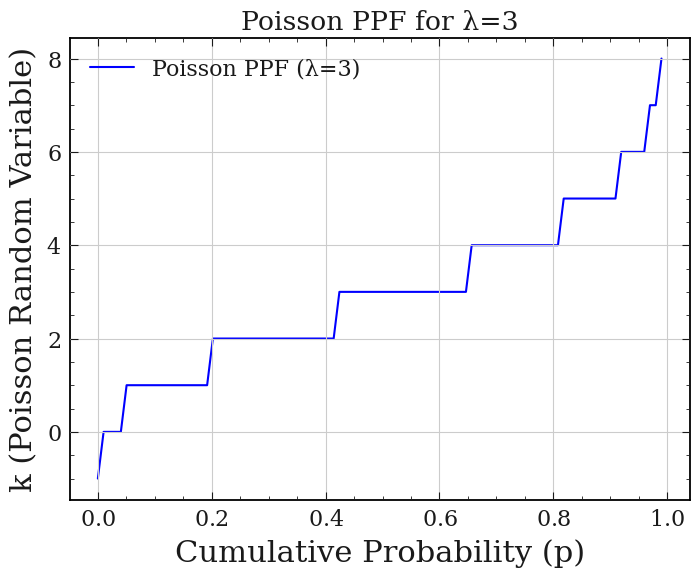

In [66]:
# Parameters
lambda_ = 3

# Values for cumulative probability
p_values = np.linspace(0, 1, 100)

# Poisson PPF (inverse of the CDF)
k_values = poisson.ppf(p_values, lambda_)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(p_values, k_values, label=f'Poisson PPF (λ={lambda_})', color='b')
plt.title(f'Poisson PPF for λ={lambda_}')
plt.xlabel('Cumulative Probability (p)')
plt.ylabel('k (Poisson Random Variable)')
plt.grid(True)
plt.legend()
plt.show()

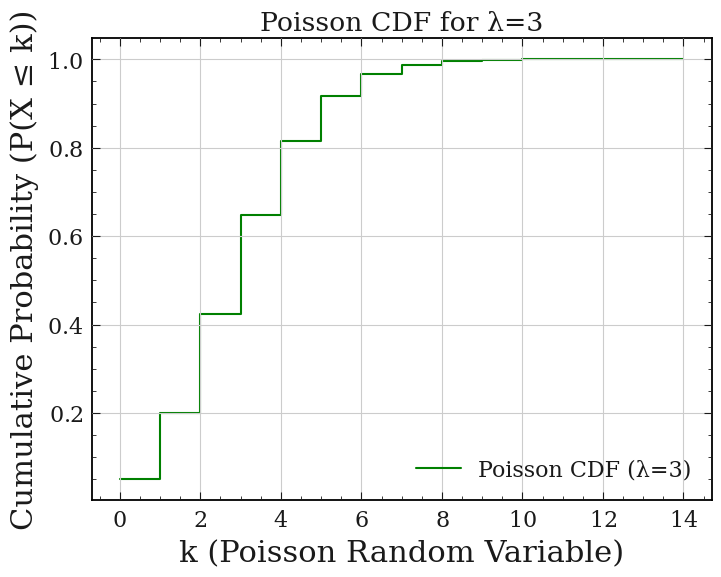

In [67]:
# Parameters
lambda_ = 3

# Values for k (possible outcomes)
k_values = np.arange(0, 15)

# Poisson CDF
cdf_values = poisson.cdf(k_values, lambda_)

# Plotting
plt.figure(figsize=(8, 6))
plt.step(k_values, cdf_values, label=f'Poisson CDF (λ={lambda_})', color='g', where='post')
plt.title(f'Poisson CDF for λ={lambda_}')
plt.xlabel('k (Poisson Random Variable)')
plt.ylabel('Cumulative Probability (P(X ≤ k))')
plt.grid(True)
plt.legend()
plt.show()

In [23]:
from scipy.stats import poisson
n = 3
alpha = 1 - 0.6827

λ_up = poisson.ppf(1 - alpha/2, n+1)  # → 6.0
λ_up

6.0

In [24]:
poisson.cdf(n, λ_up)  # ≈ 0.8413 → 즉, 1 - α/2

0.15120388277664784

In [82]:
# Parameters
lambda_ = 3  # Poisson parameter
alpha = 0.32  # For 1-sigma confidence level (68% CL)

# Observed number of events (k)
k = 5  # Example value for the number of events

# Garwood method - calculate lower and upper bounds for 1-sigma CL
lower_bound = poisson.ppf(alpha/2, lambda_)  # Lower bound
upper_bound = poisson.ppf(1 - alpha/2, lambda_)  # Upper bound

# Printing the results
print(f"For λ={lambda_} and observed k={k}:")
print(f"Lower bound (1-sigma): {lower_bound}")
print(f"Upper bound (1-sigma): {upper_bound}")

For λ=3 and observed k=5:
Lower bound (1-sigma): 1.0
Upper bound (1-sigma): 5.0
